In [1]:
import numpy as np

import numpy.linalg as la

import matplotlib.pyplot as plt

import cv2

from PIL import Image

import pickle

import os

In [2]:
DATA_DIR = './cifar-10-batches-py'

# Load a single CIFAR-10 batch from disk
def load_batch(filepath):

    with open(filepath, 'rb') as f:

        d = pickle.load(f, encoding='bytes')

    images = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    labels = np.array(d[b'labels'])

    return images, labels

# Load human-readable class names from batches.meta
def load_class_names(meta_filepath):

    with open(meta_filepath, 'rb') as f:

        meta = pickle.load(f, encoding='bytes')

    class_names = [name.decode('utf-8') for name in meta[b'label_names']]

    return class_names

# Load all 5 training batches and concatenate
train_batches = [load_batch(os.path.join(DATA_DIR, f'data_batch_{i}')) for i in range(1, 6)]

train_images = np.concatenate([b[0] for b in train_batches])

train_labels = np.concatenate([b[1] for b in train_batches])

# Load test batch
test_images, test_labels = load_batch(os.path.join(DATA_DIR, 'test_batch'))

# Load class names
class_names = load_class_names(os.path.join(DATA_DIR, 'batches.meta'))

print(len(train_images), len(test_images), train_images[0].shape, class_names)

50000 10000 (32, 32, 3) ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# Histogram of Canny Edge Responses
# Divide the Canny binary edge map into an n_cells x n_cells spatial grid.
# Record edge pixel density (fraction of edge pixels) per cell.
# Result: 16-dim L2-normalised spatial edge-density vector.
def extract_canny(img_rgb, n_cells=4, low=50, high=150):

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    edges = cv2.Canny(gray, low, high)

    h, w = edges.shape

    ch, cw = h // n_cells, w // n_cells

    feat = []

    for i in range(n_cells):

        for j in range(n_cells):

            feat.append(edges[i * ch:(i + 1) * ch, j * cw:(j + 1) * cw].mean())

    feat = np.array(feat, dtype=np.float32) / 255.0

    feat = feat / (la.norm(feat) + 1e-7)

    return feat

feat_test = extract_canny(train_images[0])

assert feat_test.shape == (16,)

assert feat_test.dtype == np.float32

# Histogram of Sobel Edge Responses
# Compute per-pixel gradient magnitude via Sobel operators in x and y.
# Bin magnitudes into n_bins buckets over the full response range [0, 1500].
# Result: 32-dim L2-normalised magnitude-distribution histogram.
def extract_sobel(img_rgb, n_bins=32):

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

    hist, _ = np.histogram(magnitude.ravel(), bins=n_bins, range=(0.0, 1500.0))

    feat = hist.astype(np.float32)

    feat = feat / (la.norm(feat) + 1e-7)

    return feat

feat_test = extract_sobel(train_images[0])

assert feat_test.shape == (32,)

assert feat_test.dtype == np.float32

In [4]:
k = 10

N_QUERIES = 100

TOTAL_RELEVANT = 5000

db_features_canny = np.zeros((len(train_images), 16), dtype=np.float32)

db_features_sobel = np.zeros((len(train_images), 32), dtype=np.float32)

# Compute both edge features for every training image in a single pass
for i in range(len(train_images)):

    db_features_canny[i] = extract_canny(train_images[i])

    db_features_sobel[i] = extract_sobel(train_images[i])

    if i % 10000 == 0:

        print(f'Processed {i}/50000')

assert db_features_canny.shape == (50000, 16)

assert db_features_sobel.shape == (50000, 32)

print(db_features_canny.shape, db_features_canny.dtype)

print(db_features_sobel.shape, db_features_sobel.dtype)

Processed 0/50000


Processed 10000/50000


Processed 20000/50000


Processed 30000/50000


Processed 40000/50000


(50000, 16) float32
(50000, 32) float32


In [5]:
# Retrieve top-k nearest neighbours by L2 distance
def retrieve(query_vec, db_features, k=10):

    dists = la.norm(db_features - query_vec, axis=1)

    top_k_idx = np.argsort(dists)[:k]

    return top_k_idx, dists[top_k_idx]

# Smoke test retrieval with Canny features
query_vec = db_features_canny[0]

top_k_idx, top_k_dists = retrieve(query_vec, db_features_canny, k=10)

assert len(top_k_idx) == 10

assert top_k_dists[0] <= top_k_dists[-1]

print(top_k_idx, top_k_dists)

[    0 26782 34951 14251 10600 35415 16913 39549 28277  1526] [0.         0.12385847 0.12486681 0.1278999  0.13283807 0.14006178
 0.14070937 0.14101961 0.14179713 0.14470486]


In [6]:
# Fraction of retrieved results matching the query label
def precision_at_k(query_label, retrieved_labels, k):

    count = np.sum(retrieved_labels[:k] == query_label)

    return count / k

# Fraction of all relevant items retrieved in top-k
def recall_at_k(query_label, retrieved_labels, k, total_relevant):

    count = np.sum(retrieved_labels[:k] == query_label)

    return count / total_relevant

# Reciprocal rank of the first correct result
def reciprocal_rank(query_label, retrieved_labels):

    for i, label in enumerate(retrieved_labels):

        if label == query_label:

            return 1.0 / (i + 1)

    return 0.0

np.random.seed(42)

query_indices = np.random.choice(len(test_images), size=N_QUERIES, replace=False)

descriptors = [('Canny', extract_canny, db_features_canny), ('Sobel', extract_sobel, db_features_sobel)]

results = {}

for name, extractor, db_features in descriptors:

    precisions = []

    recalls = []

    rr_scores = []

    for qi in query_indices:

        q_img = test_images[qi]

        q_label = test_labels[qi]

        q_feat = extractor(q_img)

        top_k_idx, _ = retrieve(q_feat, db_features, k=k)

        retrieved_labels = train_labels[top_k_idx]

        precisions.append(precision_at_k(q_label, retrieved_labels, k))

        recalls.append(recall_at_k(q_label, retrieved_labels, k, TOTAL_RELEVANT))

        rr_scores.append(reciprocal_rank(q_label, retrieved_labels))

    results[name] = (np.mean(precisions), np.mean(recalls), np.mean(rr_scores))

print(f'Descriptor | P@{k}  | R@{k}  | MRR')

for name, (p, r, mrr) in results.items():

    print(f'{name:<10} | {p:.3f} | {r:.3f} | {mrr:.3f}')

Descriptor | P@10  | R@10  | MRR
Canny      | 0.220 | 0.000 | 0.387
Sobel      | 0.185 | 0.000 | 0.288


Canny


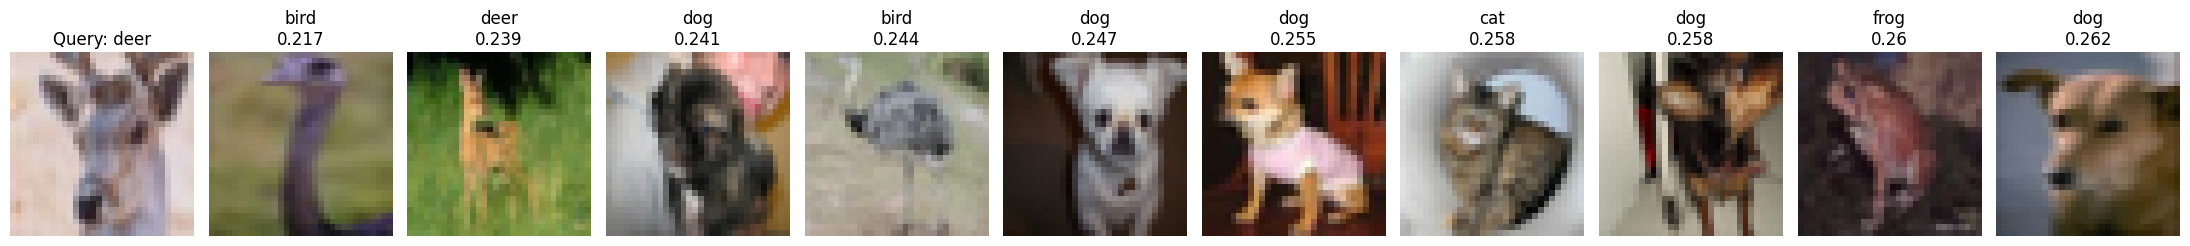

Sobel


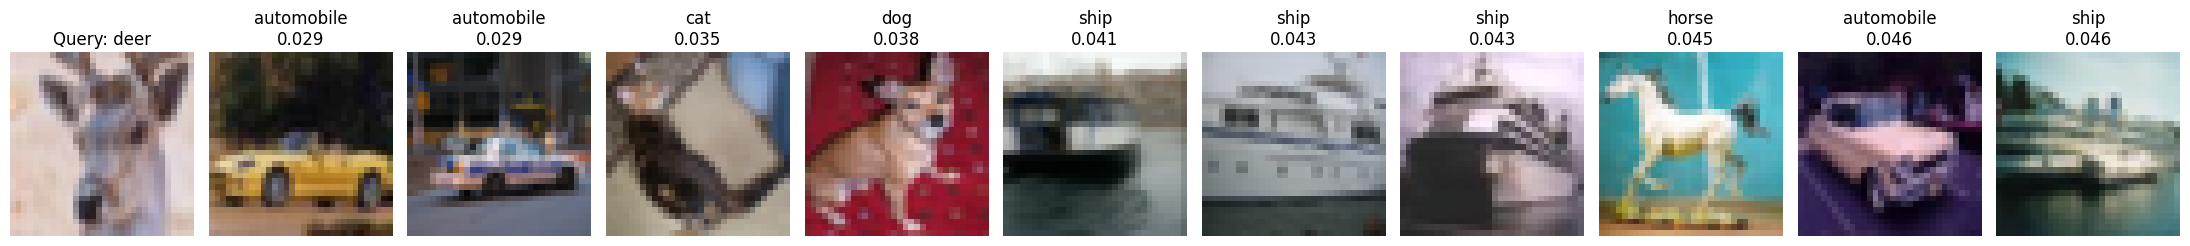

In [7]:
# Display query image and its top-k retrieved neighbours
def show_retrieval(query_img, query_label, top_k_imgs, top_k_labels, top_k_dists, class_names, k=10):

    fig, axes = plt.subplots(1, k + 1, figsize=(2 * (k + 1), 3))

    axes[0].imshow(query_img)

    axes[0].set_title('Query: ' + class_names[query_label])

    axes[0].axis('off')

    for j in range(k):

        axes[j + 1].imshow(top_k_imgs[j])

        axes[j + 1].set_title(class_names[top_k_labels[j]] + '\n' + str(round(top_k_dists[j], 3)))

        axes[j + 1].axis('off')

    plt.tight_layout()

    plt.show()

# Demo retrieval on a random test image for both descriptors
sample_idx = np.random.randint(len(test_images))

query_img = test_images[sample_idx]

query_label = test_labels[sample_idx]

for name, extractor, db_features in descriptors:

    query_feat = extractor(query_img)

    top_k_idx, top_k_dists = retrieve(query_feat, db_features, k=k)

    top_k_imgs = train_images[top_k_idx]

    top_k_labels = train_labels[top_k_idx]

    print(name)

    show_retrieval(query_img, query_label, top_k_imgs, top_k_labels, top_k_dists, class_names, k=k)